In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


uci = pd.read_csv("../data/raw/SMSSpamCollection", sep="\t", 
                  names=["label", "text"], encoding="utf-8")

uci["label"] = uci["label"].map({"spam": "Spam", "ham": "Personal"})

# synthetic = pd.read_csv("../data/processed/synthetic_sms.csv")
synthetic = pd.read_csv("../data/processed/v2/synthetic_sms.csv")


df = pd.concat([uci[["text", "label"]], synthetic], ignore_index=True)
print(df.shape)
df.head()

(15472, 3)


,text,label,template_id
0,"Go until jurong point, crazy.. Available only ...",Personal,NaN
1,Ok lar... Joking wif u oni...,Personal,NaN
2,Free entry in 2 a wkly comp to win FA Cup fina...,Spam,NaN
3,U dun say so early hor... U c already then say...,Personal,NaN
4,"Nah I don't think he goes to usf, he lives aro...",Personal,NaN


In [2]:
# getting labels count
df['label'].unique()


array(['Personal', 'Spam', 'Promo', 'Bank', 'Delivery', 'OTP'],
      dtype=object)

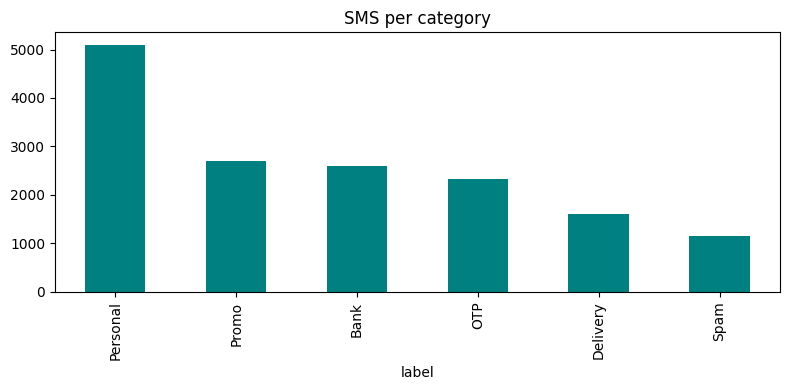

label
Personal    5100
Promo       2695
Bank        2601
OTP         2324
Delivery    1607
Spam        1145
Name: count, dtype: int64

In [3]:

plt.figure(figsize=(8, 4))
df["label"].value_counts().plot(kind="bar", color="teal")
plt.title("SMS per category")
plt.tight_layout()
plt.show()
df["label"].value_counts()

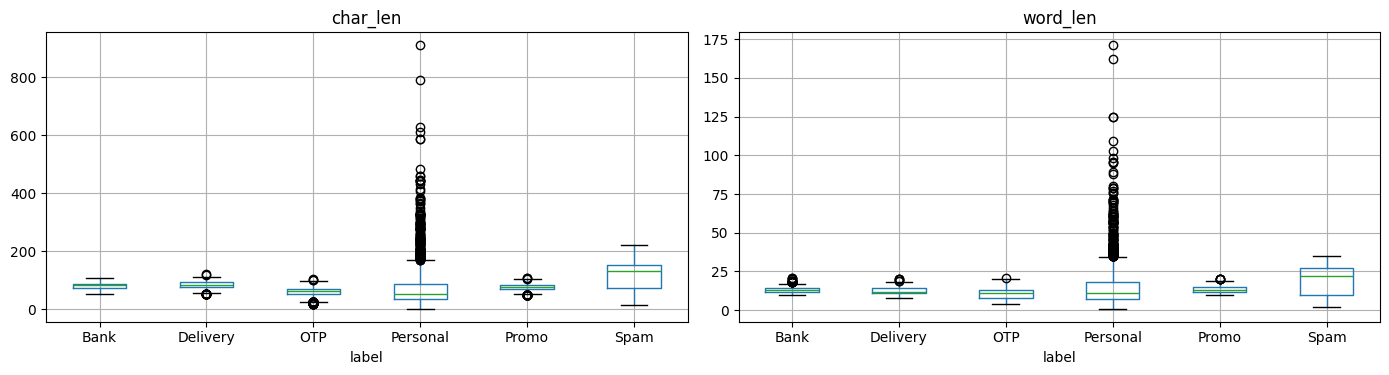

char_len                                                          \
            count        mean        std   min   25%    50%    75%    max   
label                                                                       
Bank       2194.0   80.168642   9.685798  54.0  74.0   82.0   88.0  108.0   
Delivery   1602.0   83.702871  11.880431  51.0  77.0   84.0   92.0  120.0   
OTP        2322.0   58.935831  16.640371  18.0  52.0   63.0   70.0  103.0   
Personal   5145.0   70.077551  56.896471   2.0  34.0   51.0   88.0  910.0   
Promo      1691.0   77.327025   9.800319  48.0  71.0   78.0   84.5  106.0   
Spam       1118.0  115.647585  40.592668  13.0  72.0  133.0  154.0  223.0   

         word_len                                                       
            count       mean        std   min   25%   50%   75%    max  
label                                                                   
Bank       2194.0  13.256609   1.779261  10.0  12.0  13.0  14.0   21.0  
Delivery   1602.0  12.486891   2.289785   8.0  11.0  12.0  14.0   20.0  
OTP        2322.0  10.887166   3.622922   4.0   8.0  11.0  13.0   21.0  
Personal   5145.0  14.030709  11.217273   1.0   7.0  11.0  18.0  171.0  
Promo      1691.0  13.348315   1.896718  10.0  12.0  13.0  15.0   20.0  
Spam       1118.0  19.212880   8.260710   2.0  10.0  22.0  27.0   35.0

In [6]:
# Cell 3 — Text length analysis per class
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df.boxplot(column="char_len", by="label", ax=axes[0])
df.boxplot(column="word_len", by="label", ax=axes[1])
plt.suptitle("")
plt.tight_layout()
plt.show()

df.groupby("label")[["char_len", "word_len"]].describe()

# spam char len seems to be more same for world len too

In [4]:
df.head()

,text,label,template_id
0,"Go until jurong point, crazy.. Available only ...",Personal,NaN
1,Ok lar... Joking wif u oni...,Personal,NaN
2,Free entry in 2 a wkly comp to win FA Cup fina...,Spam,NaN
3,U dun say so early hor... U c already then say...,Personal,NaN
4,"Nah I don't think he goes to usf, he lives aro...",Personal,NaN


In [5]:
from sklearn.feature_extraction.text import CountVectorizer

for label in df["label"].unique():
    texts = df[df["label"] == label]["text"]
    vec = CountVectorizer(stop_words="english", max_features=10)
    vec.fit(texts)
    print(f"{label:10s}: {list(vec.vocabulary_.keys())}")

Personal  : ['ok', 'like', 'ur', 'just', 'll', 'know', 'lt', 'gt', 'good', 'come']
Spam      : ['free', 'txt', 'customer', 'claim', 'won', 'ur', 'draw', 'bit', 'ly', 'rs']
Promo     : ['extra', 'rs', 'order', 'use', 'code', 'jul', 'bit', 'ly', 'zomato', 'free']
Bank      : ['rs', 'card', '26', 'bal', 'bank', 'credited', 'upi', 'avoid', 'balance', 'avl']
Delivery  : ['delivery', 'order', 'arriving', 'package', 'tomorrow', 'ready', 'bit', 'delivered', 'jul', 'expected']
OTP       : ['otp', 'share', 'bank', 'code', 'verify', 'use', 'valid', 'expires', 'login', 'minutes']


In [6]:

df = df.drop_duplicates(subset="text").reset_index(drop=True)
df = df[df["text"].str.len() > 10]          # drop junk
df[["text", "label"]].to_csv("../data/processed/sms_dataset.csv", index=False)
print(f"Final dataset: {len(df)} samples")
print(df["label"].value_counts())

Final dataset: 14644 samples
label
Personal    4755
Promo       2527
Bank        2380
OTP         2324
Delivery    1607
Spam        1051
Name: count, dtype: int64


# so our take away from this analysi in personal class dominates other class. there is a huge class imbalance